<a href="https://colab.research.google.com/github/suvethaaa/AI-Based-Intrusion-Detection-System/blob/main/IDS_NSL_KDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [ ]:
def binary_label(x):
    return "normal" if x == "normal" else "attack"

train_df["binary_label"] = train_df["label"].apply(binary_label)
test_df["binary_label"]  = test_df["label"].apply(binary_label)


In [12]:
# change filename if different
!wget -O KDDTrain+.txt "https://github.com/jmnwong/NSL-KDD-Dataset/raw/master/KDDTrain+.txt"
!wget -O KDDTest+.txt "https://github.com/jmnwong/NSL-KDD-Dataset/raw/master/KDDTest+.txt"
train_path = "KDDTrain+.txt"
test_path = "KDDTest+.txt"

# NSL-KDD has no header in raw form, so define column names from repo description
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label","difficulty"
]

train_df = pd.read_csv(train_path, names=columns)
test_df  = pd.read_csv(test_path,  names=columns)

train_df.head()

--2026-01-21 11:17:30--  https://github.com/jmnwong/NSL-KDD-Dataset/raw/master/KDDTrain+.txt
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt [following]
--2026-01-21 11:17:30--  https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19109424 (18M) [text/plain]
Saving to: ‘KDDTrain+.txt’

KDDTrain+.txt       100%[===================>]  18.22M  21.8MB/s    in 0.8s    

2026-01-21 11:17:31 (21.8 MB/s) - ‘KDDTrain+.txt’ saved [19109424/19109424]

--2026-01-21 11:17:31--  https:/

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
X_train = train_df.drop(columns=["label", "difficulty", "binary_label"])
y_train = train_df["binary_label"]

X_test = test_df.drop(columns=["label", "difficulty", "binary_label"])
y_test = test_df["binary_label"]


In [ ]:
categorical_cols = ["protocol_type", "service", "flag"]

# Fit encoders on train, apply to both train and test
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    encoders[col] = le


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,  # number of trees
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7731103619588361

Classification Report:
               precision    recall  f1-score   support

      attack       0.97      0.62      0.76     12833
      normal       0.66      0.97      0.79      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544


Confusion Matrix:
 [[7997 4836]
 [ 279 9432]]


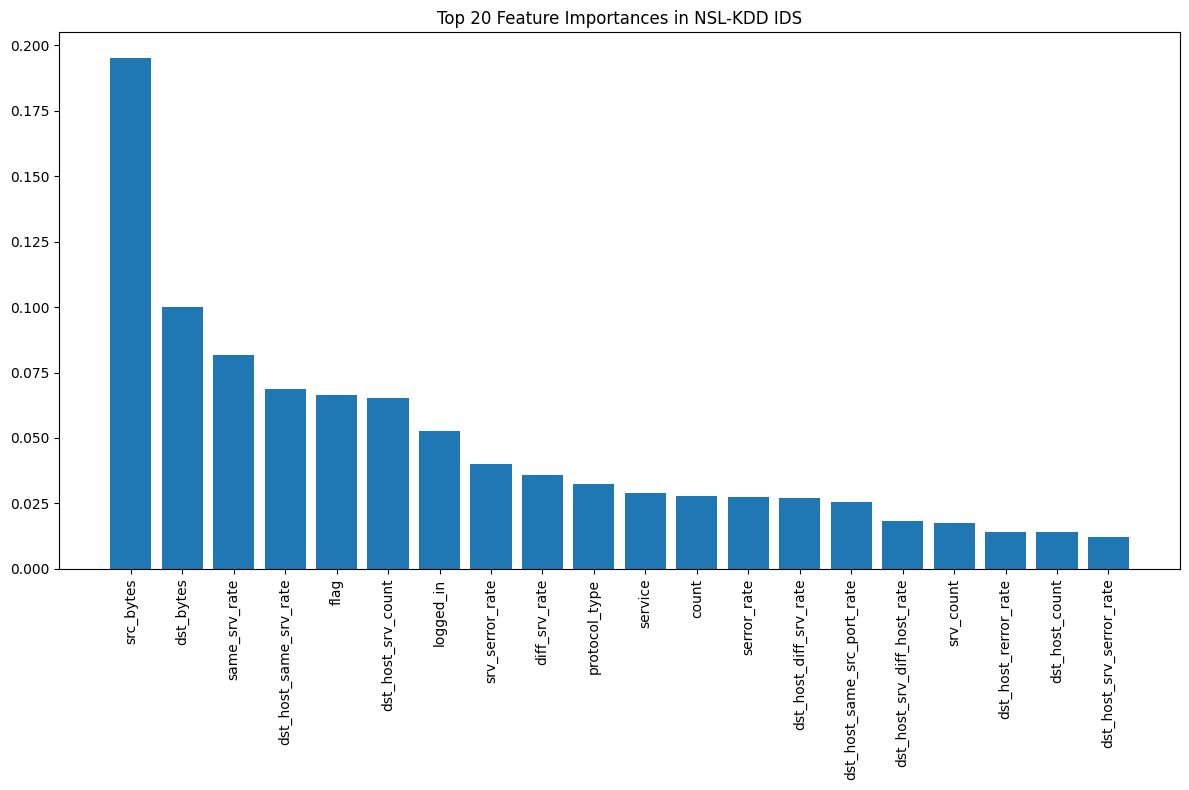

In [13]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier # Added import for RandomForestClassifier

# Initialize and train the RandomForestClassifier
# This ensures 'rf' is defined for feature importance calculation.
# Assuming X_train_scaled, y_train (for fitting) and X_train (for column names) are available from previous steps.
rf = RandomForestClassifier(
    n_estimators=100,  # number of trees
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Get feature importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]  # Top 20 features

plt.figure(figsize=(12,8))
plt.title("Top 20 Feature Importances in NSL-KDD IDS")
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [X_train.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

In [4]:
# 1. Re-imports (if needed)
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt


In [5]:
# 2. Reload data (if files are gone, re-run wget)
!wget -O KDDTrain+.txt "https://github.com/jmnwong/NSL-KDD-Dataset/raw/master/KDDTrain+.txt"
!wget -O KDDTest+.txt "https://github.com/jmnwong/NSL-KDD-Dataset/raw/master/KDDTest+.txt"

columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

train_df = pd.read_csv("KDDTrain+.txt", names=columns)
test_df = pd.read_csv("KDDTest+.txt", names=columns)


--2026-01-21 10:58:03--  https://github.com/jmnwong/NSL-KDD-Dataset/raw/master/KDDTrain+.txt
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt [following]
--2026-01-21 10:58:03--  https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19109424 (18M) [text/plain]
Saving to: ‘KDDTrain+.txt’

KDDTrain+.txt       100%[===================>]  18.22M  51.3MB/s    in 0.4s    

2026-01-21 10:58:05 (51.3 MB/s) - ‘KDDTrain+.txt’ saved [19109424/19109424]

--2026-01-21 10:58:05--  https:/

In [6]:
# 3. Binary labels
def binary_label(x):
    return "normal" if x == "normal" else "attack"

train_df["binary_label"] = train_df["label"].apply(binary_label)
test_df["binary_label"] = test_df["label"].apply(binary_label)


In [7]:
# 4. Split features/labels
X_train = train_df.drop(columns=["label", "difficulty", "binary_label"])
y_train = train_df["binary_label"]
X_test = test_df.drop(columns=["label", "difficulty", "binary_label"])
y_test = test_df["binary_label"]


In [8]:
# 5. Encode categorical
categorical_cols = ["protocol_type", "service", "flag"]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le


In [9]:
# 6. Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
# 7. Train Random Forest (takes 1-2 minutes)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

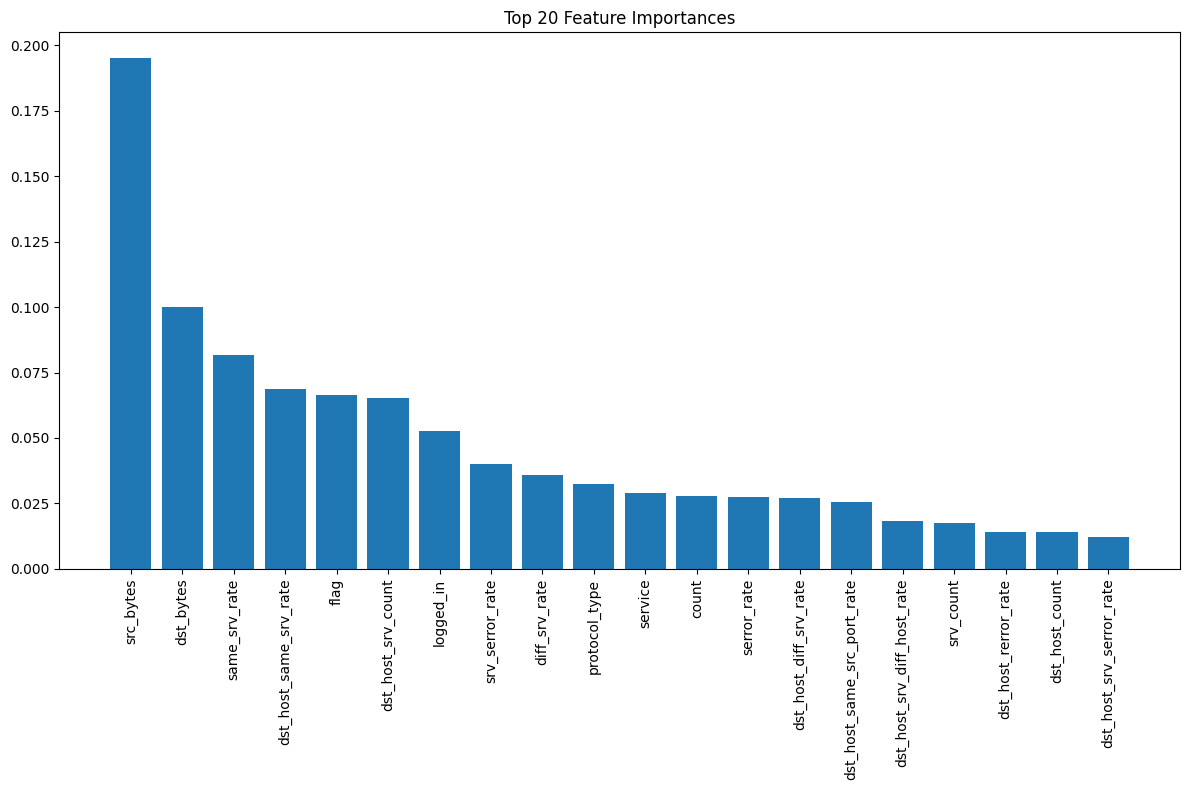

In [11]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]
plt.figure(figsize=(12,8))
plt.title("Top 20 Feature Importances")
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [X_train.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()
